In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, classification_report

In [ ]:
df = pd.read_csv("spam.csv", encoding='latin')
df.head()

,Category,Message
0,ham,Your meeting is scheduled on 1977-07-29 at 00:...
1,ham,Thank you for your order #3725.
2,ham,"Hi, David, please review the attached document."
3,ham,"Hi, Raymond, please review the attached document."
4,ham,Your meeting is scheduled on 2024-07-28 at 07:...


In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5500 non-null   object
 1   Message   5500 non-null   object
dtypes: object(2)
memory usage: 86.1+ KB
None


In [ ]:
print("Shape->",df.shape)
print("Columns->",df.columns)
print("Null->",df.isnull().sum())
print("Duplicate->",df.duplicated().sum())

Shape-> (5500, 2)
Columns-> Index(['Category', 'Message'], dtype='object')
Null-> Category    0
Message     0
dtype: int64
Duplicate-> 1821


In [ ]:
df = df.rename(columns={'v1': 'Category', 'v2': 'Message'})
df.head()

,Category,Message
0,ham,Your meeting is scheduled on 1977-07-29 at 00:...
1,ham,Thank you for your order #3725.
2,ham,"Hi, David, please review the attached document."
3,ham,"Hi, Raymond, please review the attached document."
4,ham,Your meeting is scheduled on 2024-07-28 at 07:...


In [ ]:
ham = df[df["Category"] == "ham"]["Category"].count()
spam = df[df["Category"] == "spam"]["Category"].count()
print("Total Ham Emails :", ham)
print("Total Spam Emails :", spam)

Total Ham Emails : 4800
Total Spam Emails : 700


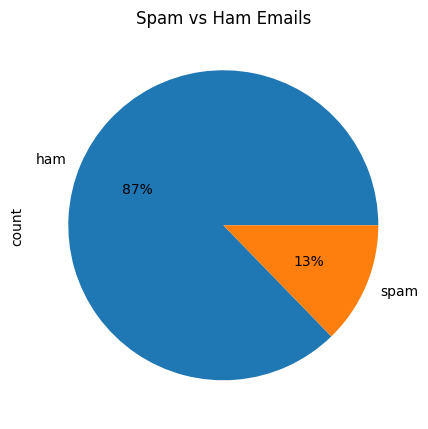

In [ ]:
df['Category'].value_counts().plot(
    kind='pie',
    autopct='%1.f%%',
    figsize=(5,6),
)
plt.title('Spam vs Ham Emails')
plt.show()

In [ ]:
df['Category'] = df['Category'].map({'ham':0,'spam':1})

In [ ]:
X = df['Message']
y = df['Category']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
def clean_text(text):
  text = text.lower()
  text = text.upper()
  return text.strip()

In [ ]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [ ]:
model = MultinomialNB(alpha=0.1)
model.fit(X_train, y_train)

MultinomialNB(alpha=0.1)

In [ ]:
train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train,train_pred)
print("Training Accuracy:", train_acc)

Training Accuracy: 1.0


In [ ]:
test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test,test_pred)
print("Testing Accuracy:", test_acc)

Testing Accuracy: 1.0


In [ ]:
cm = confusion_matrix(y_test,test_pred)

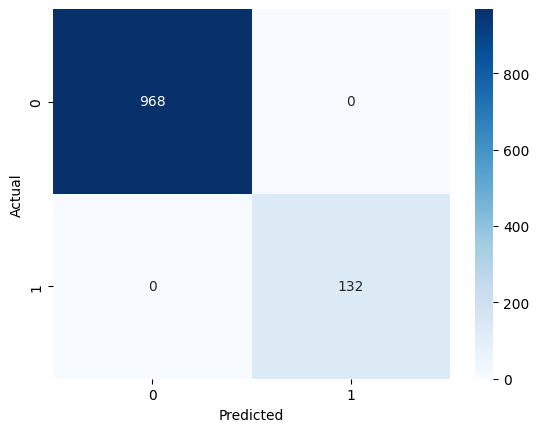

In [ ]:
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print("Precision:",precision_score(y_test, test_pred))
print("Recall:",recall_score(y_test, test_pred))
print("F1 Score:",f1_score(y_test, test_pred))

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [ ]:
print(classification_report(y_test,test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       968
           1       1.00      1.00      1.00       132

    accuracy                           1.00      1100
   macro avg       1.00      1.00      1.00      1100
weighted avg       1.00      1.00      1.00      1100



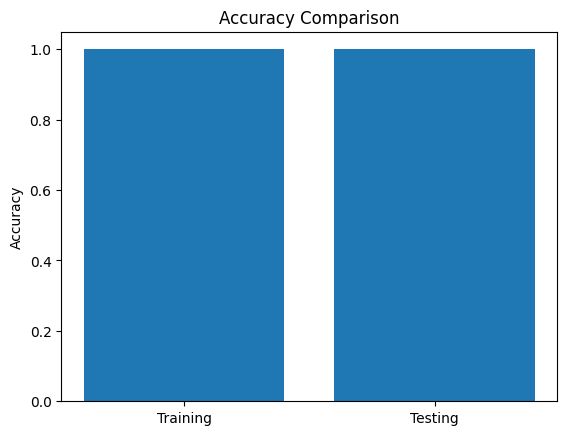

In [ ]:
accuracy = [train_acc, test_acc]
labels = ['Training', 'Testing']
plt.bar(labels, accuracy)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.show()

In [ ]:
n = int(input("How many emails do you want to check? "))
for i in range(n):
    msg = input(f"\nEnter Email {i+1}: ")
    data = vectorizer.transform([msg])
    prediction = model.predict(data)
    if prediction[0] == 1:
        print("Result: Spam Email")
    else:
        print("Result: Ham Email")

#Heyy, won a lottery of 500000!!!!d
#There is a meeting at 5:00 PM.

How many emails do you want to check? 4

Enter Email 1: Heyy, won a lottery of 500000!!!!d
Result: Spam Email

Enter Email 2: There is a meeting at 5:00 PM.
Result: Ham Email


KeyboardInterrupt: 